# Diabetes Risk Digital Twin: Stages 1, 2, and 3

This notebook is the reproducible experiment source for the implemented research path:

- **Stage 1 / RQ1:** How well can a class-weighted Random Forest distinguish Low, Medium/prediabetes, and High/diabetes BRFSS labels?
- **Stage 2 / RQ2:** Which variables matter globally, and which variables support or oppose representative patient-level predictions?
- **Stage 3 / RQ3:** Can a Digital Twin compare the same model before and after transparent manual input edits?

The rebuild removes duplicate metric computation, prevents identical feature profiles from crossing the train/test boundary, validates class and SHAP shapes, explains multiple deterministic cases, and records the actual permutation workload.

> **Research only:** BRFSS is cross-sectional survey data. Predictions, SHAP values, and manually edited scenarios are model-based associations, not diagnoses, medical causes, or treatment effects.


## 1. Experiment plan and success criteria

A successful top-to-bottom run must:

1. retain the 21-feature public data contract and stable one-based dataset numbering;
2. report duplicate-profile counts before splitting and assert zero profile overlap after splitting;
3. train the model once and compute Stage 1 predictions/metrics once;
4. fail with a clear message if any expected class or SHAP dimension is missing;
5. save global importance and 3-5 representative local SHAP cases; and
6. assert that `metrics.json` and `results_summary.json` describe the same run.


## 2. Install packages (run only when needed)

The Docker training image installs the pinned project requirements. Avoid upgrading scikit-learn or SHAP inside an already-running notebook because serialized estimator and explanation formats are version-sensitive.


In [1]:
# %pip install -r requirements.txt


In [2]:
from pathlib import Path
import json
import os
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap  # type: ignore[import-not-found]

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
DATA_PATH = Path("diabetes_012_health_indicators_BRFSS2015.csv")
ARTIFACTS = Path(os.environ.get("NOTEBOOK_ARTIFACT_DIR", "artifacts_notebook"))
ARTIFACTS.mkdir(parents=True, exist_ok=True)

FAST_MODE = os.environ.get("NOTEBOOK_FAST_MODE", "0") == "1"
N_ESTIMATORS = 40 if FAST_MODE else 400
PERMUTATION_SAMPLE_SIZE = 200 if FAST_MODE else 1000
PERMUTATION_REPEATS = 1 if FAST_MODE else 3
PERMUTATION_N_JOBS = int(os.environ.get("PERMUTATION_N_JOBS", "1"))
if PERMUTATION_N_JOBS < 1:
    raise ValueError("PERMUTATION_N_JOBS must be a positive integer.")

TARGET = "Diabetes_012"
FEATURES = [
    "HighBP", "HighChol", "CholCheck", "BMI", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "GenHlth",
    "MentHlth", "PhysHlth", "DiffWalk", "Sex", "Age", "Education", "Income",
]
RISK_LABELS = {0: "Low", 1: "Medium (prediabetes)", 2: "High (diabetes)"}
EXPECTED_CLASSES = np.array(sorted(RISK_LABELS))

print(
    f"Mode: {'FAST smoke test' if FAST_MODE else 'FULL experiment'}; "
    f"artifacts: {ARTIFACTS.resolve()}"
)


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mode: FULL experiment; artifacts: /app/artifacts_notebook


## 3. Load data and audit duplicates before splitting

Exact duplicate survey responses may represent different participants, so this notebook does not silently delete them. Instead, it groups identical 21-feature profiles during splitting. This prevents the same model input from appearing in both train and test while preserving participant rows and original dataset numbering.


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

source_df = pd.read_csv(DATA_PATH)
missing = set(FEATURES + [TARGET]) - set(source_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df = source_df[FEATURES + [TARGET]].copy()
df["dataset_patient_number"] = np.arange(1, len(df) + 1)
df[FEATURES] = df[FEATURES].apply(pd.to_numeric, errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

rows_before_cleaning = len(df)
df = df.dropna(subset=FEATURES + [TARGET]).copy()
df[TARGET] = df[TARGET].astype(int)
df = df[df[TARGET].isin(EXPECTED_CLASSES)].copy()

exact_duplicate_rows = int(df.duplicated(subset=FEATURES + [TARGET]).sum())
repeated_feature_rows = int(df.duplicated(subset=FEATURES).sum())
conflicting_profiles = int(
    df.groupby(FEATURES, dropna=False)[TARGET].nunique().gt(1).sum()
)

duplicate_audit = {
    "rows_before_cleaning": rows_before_cleaning,
    "rows_after_cleaning": len(df),
    "exact_duplicate_rows_beyond_first": exact_duplicate_rows,
    "repeated_feature_rows_beyond_first": repeated_feature_rows,
    "feature_profiles_with_conflicting_targets": conflicting_profiles,
    "policy": "Preserve participant rows; group identical feature profiles during split.",
}
(ARTIFACTS / "duplicate_audit.json").write_text(
    json.dumps(duplicate_audit, indent=2), encoding="utf-8"
)
display(pd.Series(duplicate_audit, name="value").to_frame())

X = df[FEATURES].astype(float)
y = df[TARGET].astype(int)
class_summary = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percentage": y.value_counts(normalize=True).sort_index().mul(100),
})
class_summary.index = [RISK_LABELS[int(i)] for i in class_summary.index]
display(class_summary.style.format({"percentage": "{:.2f}%"}))


,value
rows_before_cleaning,253680
rows_after_cleaning,253680
exact_duplicate_rows_beyond_first,23899
repeated_feature_rows_beyond_first,25772
feature_profiles_with_conflicting_targets,1834
policy,Preserve participant rows; group identical fea...


,count,percentage
Low,213703,84.24%
Medium (prediabetes),4631,1.83%
High (diabetes),35346,13.93%


## 4. Leakage-resistant stratified group split

A five-fold `StratifiedGroupKFold` candidate set is built from hashes of the 21-feature profiles. The fold closest to a 20% test size and the full-dataset class proportions is selected deterministically. The overlap assertion is the acceptance test for duplicate-profile leakage.


In [4]:
profile_groups = pd.util.hash_pandas_object(X, index=False).to_numpy()
splitter = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

overall_distribution = y.value_counts(normalize=True).reindex(EXPECTED_CLASSES, fill_value=0)

def split_score(train_position, test_position):
    test_y = y.iloc[test_position]
    test_distribution = test_y.value_counts(normalize=True).reindex(
        EXPECTED_CLASSES, fill_value=0
    )
    size_error = abs(len(test_position) / len(y) - 0.20)
    distribution_error = float((test_distribution - overall_distribution).abs().sum())
    return size_error + distribution_error

candidate_splits = list(splitter.split(X, y, groups=profile_groups))
train_position, test_position = min(candidate_splits, key=lambda pair: split_score(*pair))

X_train, X_test = X.iloc[train_position].copy(), X.iloc[test_position].copy()
y_train, y_test = y.iloc[train_position].copy(), y.iloc[test_position].copy()
patient_numbers_test = df.iloc[test_position]["dataset_patient_number"].copy()

train_groups = set(profile_groups[train_position])
test_groups = set(profile_groups[test_position])
profile_overlap = train_groups.intersection(test_groups)
assert not profile_overlap, (
    f"Leakage guard failed: {len(profile_overlap)} identical feature profiles "
    "appear in both train and test."
)
if set(y_test.unique()) != set(EXPECTED_CLASSES):
    missing_classes = sorted(set(EXPECTED_CLASSES) - set(y_test.unique()))
    raise RuntimeError(f"Test split is missing expected classes: {missing_classes}")

split_audit = {
    "n_rows": len(X),
    "n_train": len(X_train),
    "n_test": len(X_test),
    "test_fraction": len(X_test) / len(X),
    "train_unique_profiles": len(train_groups),
    "test_unique_profiles": len(test_groups),
    "cross_split_profile_overlap": len(profile_overlap),
}
(ARTIFACTS / "split_audit.json").write_text(
    json.dumps(split_audit, indent=2), encoding="utf-8"
)
display(pd.Series(split_audit, name="value").to_frame())
display(pd.crosstab(y_test, columns="test count").rename(index=RISK_LABELS))


,value
n_rows,253680.00000
n_train,203015.00000
n_test,50665.00000
test_fraction,0.19972
train_unique_profiles,182380.00000
test_unique_profiles,45528.00000
cross_split_profile_overlap,0.00000


col_0,test count
Diabetes_012,
Low,42619
Medium (prediabetes),918
High (diabetes),7128


## 5. Train the Stage 1 model once


In [5]:
model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    class_weight="balanced_subsample",
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
training_started = time.perf_counter()
model.fit(X_train, y_train)
training_seconds = time.perf_counter() - training_started

if not np.array_equal(model.classes_, EXPECTED_CLASSES):
    raise RuntimeError(
        f"Unexpected fitted classes {model.classes_.tolist()}; "
        f"expected {EXPECTED_CLASSES.tolist()}."
    )
joblib.dump(model, ARTIFACTS / "diabetes_risk_random_forest.joblib", compress=3)
print(
    f"Saved {N_ESTIMATORS}-tree model with classes {model.classes_.tolist()} "
    f"after {training_seconds:.1f} seconds."
)


Saved 400-tree model with classes [0, 1, 2] after 26.2 seconds.


## 6. Stage 1 evaluation (single source of truth)

This is the only cell that computes held-out predictions, probabilities, classification metrics, and the confusion matrix. Both report-facing JSON files are derived from this state.


,precision,recall,f1-score,support
Low,0.8945,0.9033,0.8989,42619.0000
Medium (prediabetes),0.0500,0.0022,0.0042,918.0000
High (diabetes),0.4222,0.4494,0.4354,7128.0000
accuracy,0.8231,0.8231,0.8231,0.8231
macro avg,0.4556,0.4516,0.4461,50665.0000
weighted avg,0.8127,0.8231,0.8175,50665.0000


,score
accuracy,0.8231
balanced_accuracy,0.4516
macro_f1,0.4461
weighted_f1,0.8175
macro_ovr_roc_auc,0.7575


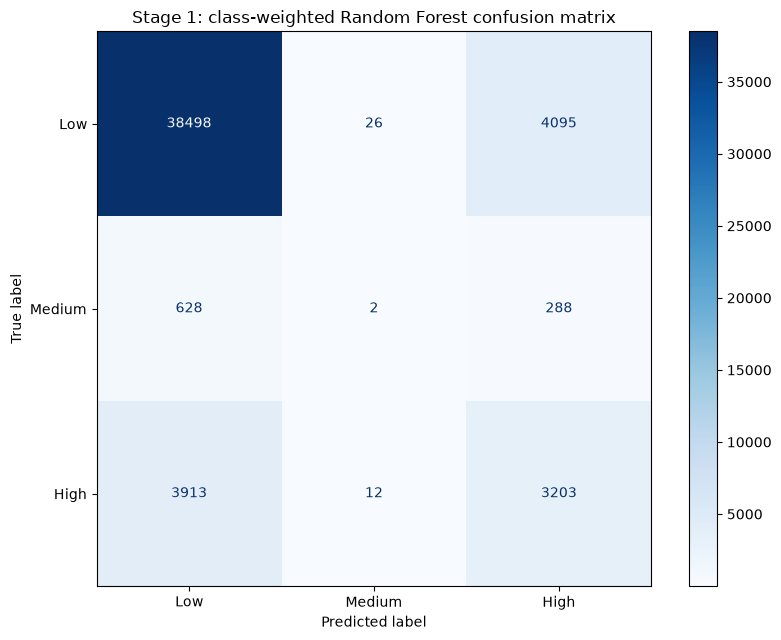

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

def guarded_macro_ovr_auc(y_true, probability_matrix, classes):
    observed = np.array(sorted(pd.Series(y_true).unique()))
    if not np.array_equal(observed, classes):
        missing_classes = sorted(set(classes) - set(observed))
        raise RuntimeError(
            "Cannot compute multiclass ROC-AUC because the held-out split "
            f"is missing classes: {missing_classes}"
        )
    expected_shape = (len(y_true), len(classes))
    if probability_matrix.shape != expected_shape:
        raise RuntimeError(
            f"Probability shape {probability_matrix.shape} does not match {expected_shape}."
        )
    return float(roc_auc_score(
        y_true,
        probability_matrix,
        labels=classes,
        multi_class="ovr",
        average="macro",
    ))

report_dict = classification_report(
    y_test,
    y_pred,
    labels=EXPECTED_CLASSES,
    target_names=[RISK_LABELS[int(i)] for i in EXPECTED_CLASSES],
    output_dict=True,
    zero_division=0,
)
metrics = {
    "n_rows": int(len(X)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "class_counts": {str(int(k)): int(v) for k, v in y.value_counts().sort_index().items()},
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "macro_f1": float(f1_score(y_test, y_pred, average="macro")),
    "weighted_f1": float(f1_score(y_test, y_pred, average="weighted")),
    "macro_ovr_roc_auc": guarded_macro_ovr_auc(y_test, y_prob, EXPECTED_CLASSES),
    "classification_report": report_dict,
    "split_policy": duplicate_audit["policy"],
    "cross_split_profile_overlap": int(len(profile_overlap)),
    "n_estimators": int(N_ESTIMATORS),
    "random_state": int(RANDOM_STATE),
    "training_seconds": float(training_seconds),
}
(ARTIFACTS / "metrics.json").write_text(
    json.dumps(metrics, indent=2), encoding="utf-8"
)

report = pd.DataFrame(report_dict).T
display(report.round(4))
display(pd.Series({
    key: metrics[key]
    for key in ("accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "macro_ovr_roc_auc")
}, name="score").to_frame().style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(8.5, 6.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Low", "Medium", "High"],
    cmap="Blues",
    values_format="d",
    ax=ax,
)
ax.set_title("Stage 1: class-weighted Random Forest confusion matrix")
fig.tight_layout()
fig.savefig(ARTIFACTS / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()


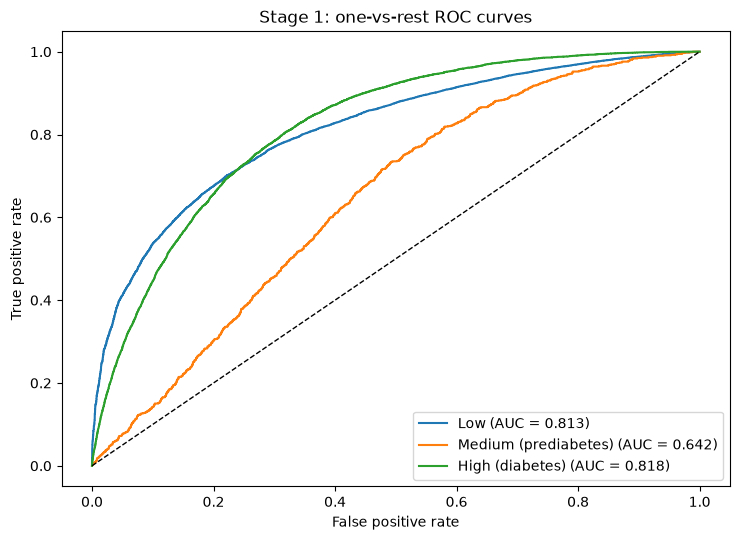

In [7]:
y_bin = label_binarize(y_test, classes=EXPECTED_CLASSES)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
per_class_auc = {}
for class_position, class_id in enumerate(EXPECTED_CLASSES):
    binary_truth = y_bin[:, class_position]
    if np.unique(binary_truth).size != 2:
        warnings.warn(f"Skipping ROC for class {class_id}: only one binary label is present.")
        continue
    fpr, tpr, _ = roc_curve(binary_truth, y_prob[:, class_position])
    class_auc = float(auc(fpr, tpr))
    per_class_auc[str(int(class_id))] = class_auc
    ax.plot(fpr, tpr, label=f"{RISK_LABELS[int(class_id)]} (AUC = {class_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="Stage 1: one-vs-rest ROC curves",
)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(ARTIFACTS / "roc_curves.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Stage 2 global explanation

Permutation importance measures the decrease in held-out macro-F1 after shuffling one feature. `PERMUTATION_N_JOBS` is an explicit runtime configuration, not a hidden methodology choice. The default remains one worker because earlier Docker runs terminated parallel workers under memory pressure; set it to 2 only while profiling available memory. If a parallel attempt fails, this cell records the failure and retries serially.


,value
sample_size,1000.000000
repeats,3.000000
requested_n_jobs,1.000000
effective_n_jobs,1.000000
elapsed_seconds,13.964391
fallback_reason,NaN


,feature,importance_mean,importance_std
3,BMI,0.025898,0.003323
13,GenHlth,0.022702,0.002498
1,HighChol,0.013498,0.000233
18,Age,0.007708,0.003925
0,HighBP,0.003189,0.011690
12,NoDocbcCost,0.002818,0.001389
2,CholCheck,0.002662,0.001387
6,HeartDiseaseorAttack,0.001026,0.002760
19,Education,0.000822,0.003024
8,Fruits,0.000422,0.003205


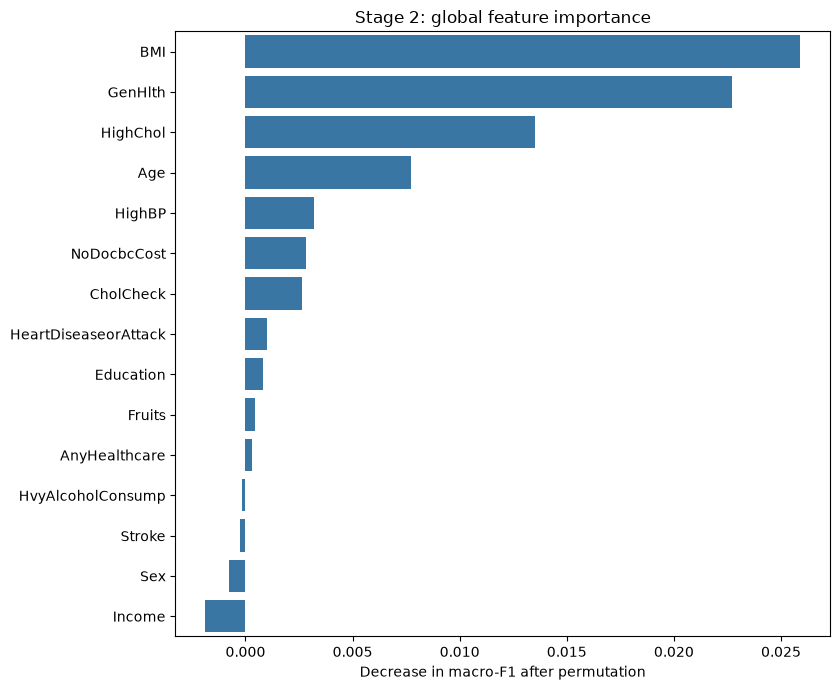

In [8]:
importance_sample = X_test.sample(
    n=min(PERMUTATION_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE
)
importance_y = y_test.loc[importance_sample.index]

def run_permutation(worker_count):
    return permutation_importance(
        model,
        importance_sample,
        importance_y,
        scoring="f1_macro",
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_STATE,
        n_jobs=worker_count,
    )

permutation_started = time.perf_counter()
effective_jobs = PERMUTATION_N_JOBS
fallback_reason = None
try:
    permutation = run_permutation(PERMUTATION_N_JOBS)
except Exception as exc:
    if PERMUTATION_N_JOBS == 1:
        raise
    fallback_reason = f"{type(exc).__name__}: {exc}"
    warnings.warn(
        "Parallel permutation importance failed; retrying with n_jobs=1. "
        f"Reason: {fallback_reason}"
    )
    effective_jobs = 1
    permutation = run_permutation(1)
permutation_seconds = time.perf_counter() - permutation_started

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values("importance_mean", ascending=False)
if not np.isfinite(importance_df[["importance_mean", "importance_std"]].to_numpy()).all():
    raise RuntimeError("Permutation importance produced non-finite values.")

importance_df.to_csv(ARTIFACTS / "global_permutation_importance.csv", index=False)
permutation_config = {
    "sample_size": int(len(importance_sample)),
    "repeats": int(PERMUTATION_REPEATS),
    "requested_n_jobs": int(PERMUTATION_N_JOBS),
    "effective_n_jobs": int(effective_jobs),
    "elapsed_seconds": float(permutation_seconds),
    "fallback_reason": fallback_reason,
}
(ARTIFACTS / "permutation_config.json").write_text(
    json.dumps(permutation_config, indent=2), encoding="utf-8"
)
display(pd.Series(permutation_config, name="value").to_frame())
display(importance_df)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature", color="#2878b5", ax=ax)
ax.set(
    xlabel="Decrease in macro-F1 after permutation",
    ylabel="",
    title="Stage 2: global feature importance",
)
fig.tight_layout()
fig.savefig(ARTIFACTS / "global_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Select representative held-out cases

The selection is deterministic and attempts to cover correct predictions and important errors: true-positive Low, Medium, and High cases; a missed Medium case; and a false High prediction. Cases that do not exist under the fitted model are reported rather than silently replaced.


In [9]:
prediction_series = pd.Series(y_pred, index=y_test.index, name="predicted_class")
probability_frame = pd.DataFrame(
    y_prob,
    index=y_test.index,
    columns=[int(class_id) for class_id in model.classes_],
)

case_masks = {
    "tp_low": (y_test == 0) & (prediction_series == 0),
    "tp_medium": (y_test == 1) & (prediction_series == 1),
    "tp_high": (y_test == 2) & (prediction_series == 2),
    "fn_medium": (y_test == 1) & (prediction_series != 1),
    "fp_high": (y_test != 2) & (prediction_series == 2),
}

selected_cases = []
unavailable_cases = []
for case_id, mask in case_masks.items():
    candidates = y_test.index[mask]
    if len(candidates) == 0:
        unavailable_cases.append(case_id)
        continue
    if case_id.startswith("tp_"):
        class_id = int(y_test.loc[candidates[0]])
        selected_index = probability_frame.loc[candidates, class_id].idxmax()
    else:
        selected_index = candidates[0]
    predicted_class = int(prediction_series.loc[selected_index])
    selected_cases.append({
        "case_id": case_id,
        "row_index": int(selected_index),
        "dataset_patient_number": int(df.loc[selected_index, "dataset_patient_number"]),
        "actual_class": int(y_test.loc[selected_index]),
        "actual_label": RISK_LABELS[int(y_test.loc[selected_index])],
        "predicted_class": predicted_class,
        "predicted_label": RISK_LABELS[predicted_class],
        "predicted_probability": float(probability_frame.loc[selected_index, predicted_class]),
        "correct": bool(int(y_test.loc[selected_index]) == predicted_class),
    })

cases_df = pd.DataFrame(selected_cases)
if len(cases_df) < 3:
    raise RuntimeError(f"Only {len(cases_df)} representative cases were available; expected at least 3.")
if "tp_high" not in set(cases_df["case_id"]):
    raise RuntimeError("A true-positive High/diabetes case is required for the Stage 3 case study.")
cases_df.to_csv(ARTIFACTS / "patient_shap_cases_summary.csv", index=False)
display(cases_df.drop(columns="row_index"))
print("Unavailable requested case types:", unavailable_cases or "none")


,case_id,dataset_patient_number,actual_class,actual_label,predicted_class,predicted_label,predicted_probability,correct
0,tp_low,25495,0,Low,0,Low,0.999898,True
1,tp_medium,138203,1,Medium (prediabetes),1,Medium (prediabetes),0.451648,True
2,tp_high,194035,2,High (diabetes),2,High (diabetes),0.904594,True
3,fn_medium,82,1,Medium (prediabetes),0,Low,0.580357,False
4,fp_high,22,0,Low,2,High (diabetes),0.769746,False


Unavailable requested case types: none


## 9. Exact patient-level SHAP for all representative cases

The helper below normalizes supported old and new SHAP output layouts to `(samples, features, classes)`. It validates the expected-value vector and checks SHAP additivity against the fitted class probability for every saved case.


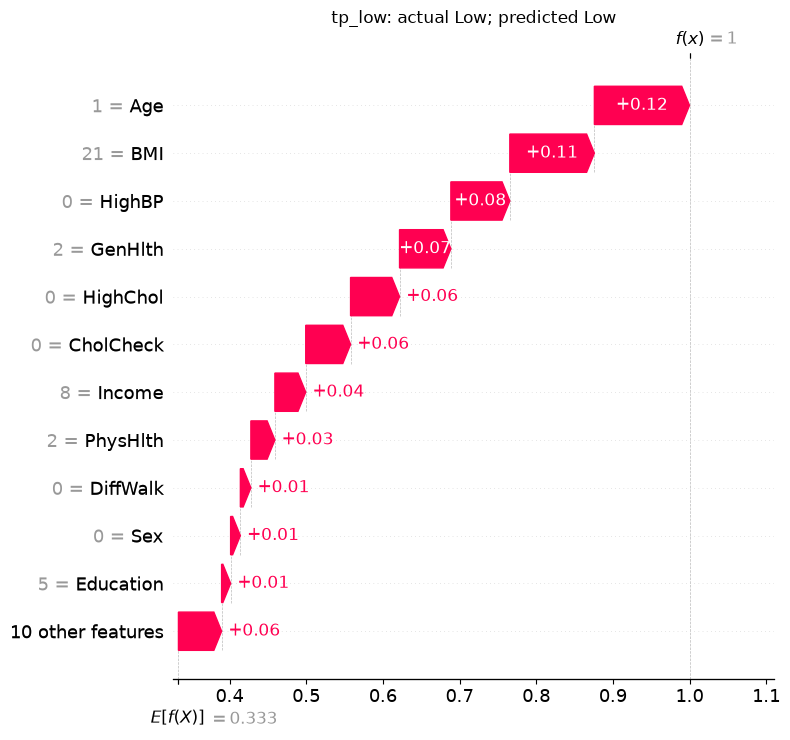

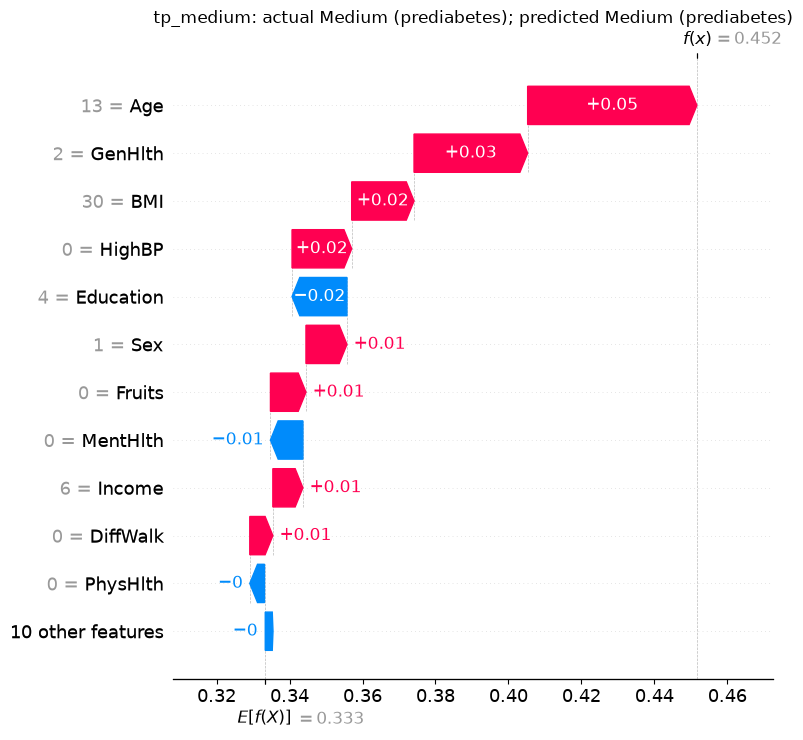

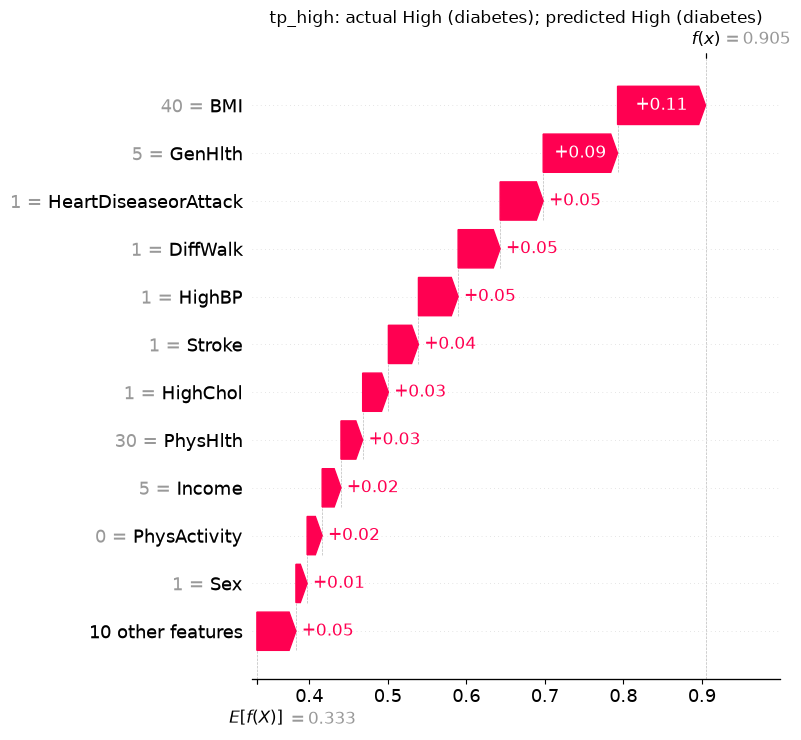

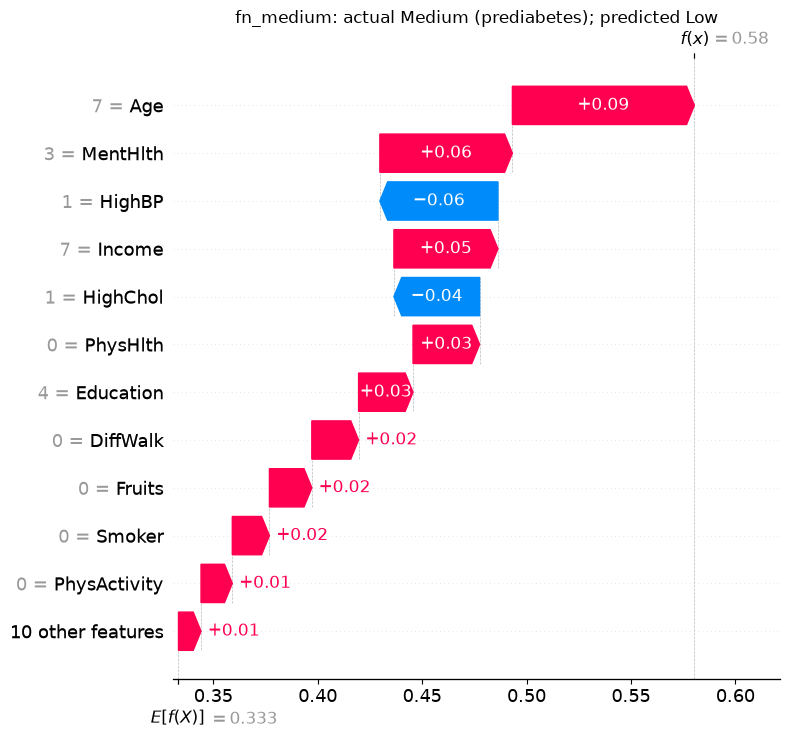

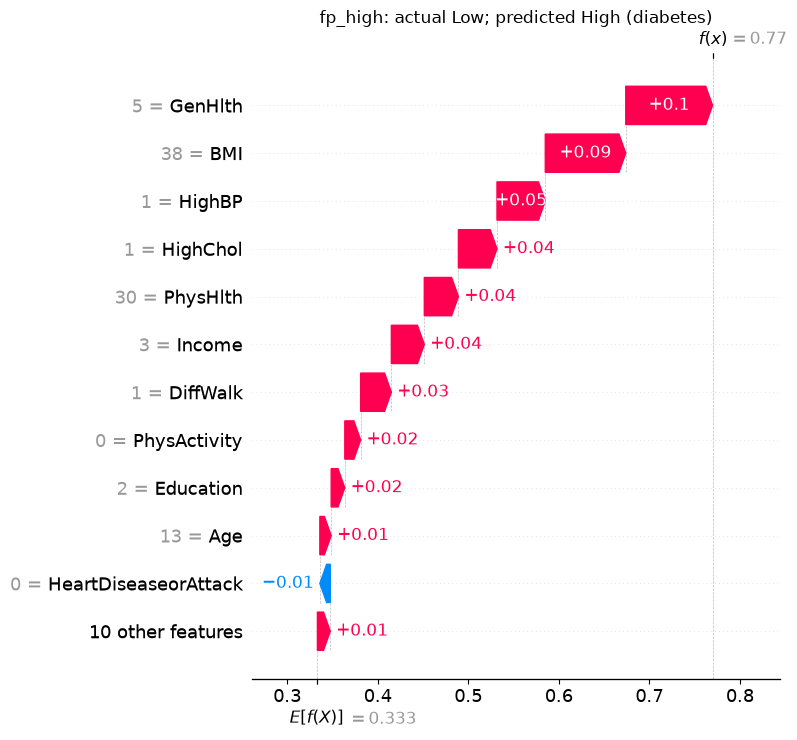

,case_id,dataset_patient_number,actual_class,predicted_class,feature,patient_value,shap_value,absolute_shap_value
0,tp_low,25495,0,0,Age,1.0,0.124092,0.124092
1,tp_low,25495,0,0,BMI,21.0,0.110273,0.110273
2,tp_low,25495,0,0,HighBP,0.0,0.076889,0.076889
3,tp_low,25495,0,0,GenHlth,2.0,0.066933,0.066933
4,tp_low,25495,0,0,HighChol,0.0,0.063879,0.063879
5,tp_medium,138203,1,1,Age,13.0,0.046388,0.046388
6,tp_medium,138203,1,1,GenHlth,2.0,0.031147,0.031147
7,tp_medium,138203,1,1,BMI,30.0,0.017088,0.017088
8,tp_medium,138203,1,1,HighBP,0.0,0.016347,0.016347
9,tp_medium,138203,1,1,Education,4.0,-0.015048,0.015048


In [10]:
explainer = shap.TreeExplainer(model)
expected_values = np.asarray(explainer.expected_value, dtype=float).reshape(-1)
if expected_values.size != len(model.classes_):
    raise RuntimeError(
        f"Unexpected SHAP expected_value shape {np.asarray(explainer.expected_value).shape}; "
        f"expected one base value for each class {model.classes_.tolist()}."
    )

def normalized_shap_values(frame):
    raw_values = explainer.shap_values(frame)
    n_samples, n_features = frame.shape
    n_classes = len(model.classes_)
    if isinstance(raw_values, list):
        if len(raw_values) != n_classes:
            raise RuntimeError(
                f"SHAP returned {len(raw_values)} class arrays; expected {n_classes}."
            )
        normalized = np.stack([np.asarray(values) for values in raw_values], axis=-1)
    else:
        array = np.asarray(raw_values)
        if array.shape == (n_samples, n_features, n_classes):
            normalized = array
        elif array.shape == (n_classes, n_samples, n_features):
            normalized = np.moveaxis(array, 0, -1)
        else:
            raise RuntimeError(
                f"Unsupported SHAP output shape {array.shape}; expected "
                f"({n_samples}, {n_features}, {n_classes})."
            )
    return np.asarray(normalized, dtype=float)

all_case_rows = []
for case in selected_cases:
    case_id = case["case_id"]
    row_index = case["row_index"]
    patient_frame = X_test.loc[[row_index]]
    predicted_class = int(case["predicted_class"])
    class_position = int(np.where(model.classes_ == predicted_class)[0][0])
    values = normalized_shap_values(patient_frame)[0, :, class_position]
    base_value = float(expected_values[class_position])
    reconstructed_probability = base_value + float(values.sum())
    model_probability = float(probability_frame.loc[row_index, predicted_class])
    if not np.isclose(reconstructed_probability, model_probability, atol=1e-5):
        raise RuntimeError(
            f"SHAP additivity failed for {case_id}: reconstructed "
            f"{reconstructed_probability:.8f}, model {model_probability:.8f}."
        )

    contributions = pd.DataFrame({
        "case_id": case_id,
        "dataset_patient_number": case["dataset_patient_number"],
        "actual_class": case["actual_class"],
        "predicted_class": predicted_class,
        "feature": FEATURES,
        "patient_value": patient_frame.iloc[0].to_numpy(),
        "shap_value": values,
    })
    contributions["absolute_shap_value"] = contributions["shap_value"].abs()
    contributions = contributions.sort_values("absolute_shap_value", ascending=False)
    contributions.to_csv(
        ARTIFACTS / f"patient_shap_{case_id}_contributions.csv", index=False
    )
    all_case_rows.append(contributions)

    explanation = shap.Explanation(
        values=values,
        base_values=base_value,
        data=patient_frame.iloc[0].to_numpy(),
        feature_names=FEATURES,
    )
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(
        f"{case_id}: actual {case['actual_label']}; "
        f"predicted {case['predicted_label']}"
    )
    plt.tight_layout()
    plt.savefig(
        ARTIFACTS / f"patient_shap_{case_id}_waterfall.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

all_case_contributions = pd.concat(all_case_rows, ignore_index=True)
all_case_contributions.to_csv(
    ARTIFACTS / "patient_shap_contributions_all_cases.csv", index=False
)

primary_case = next(case for case in selected_cases if case["case_id"] == "tp_high")
primary_contributions = all_case_contributions[
    all_case_contributions["case_id"] == "tp_high"
].copy()
primary_contributions.to_csv(
    ARTIFACTS / "patient_shap_contributions.csv", index=False
)
source_plot = ARTIFACTS / "patient_shap_tp_high_waterfall.png"
legacy_plot = ARTIFACTS / "patient_shap_waterfall.png"
legacy_plot.write_bytes(source_plot.read_bytes())

display(
    all_case_contributions.groupby("case_id", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)


## 10. Save report-ready Stage 1 and Stage 2 results


In [11]:
summary_metric_keys = (
    "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "macro_ovr_roc_auc"
)
metrics_on_disk = json.loads((ARTIFACTS / "metrics.json").read_text(encoding="utf-8"))
for key in summary_metric_keys:
    if not np.isclose(float(metrics_on_disk[key]), float(metrics[key]), atol=1e-12):
        raise RuntimeError(
            f"Artifact consistency failure for {key}: "
            f"metrics.json={metrics_on_disk[key]}, in-memory={metrics[key]}"
        )

results = {
    "dataset_rows": int(len(df)),
    "features": FEATURES,
    "class_counts": {
        RISK_LABELS[int(k)]: int(v)
        for k, v in y.value_counts().sort_index().items()
    },
    "metrics": {key: float(metrics[key]) for key in summary_metric_keys},
    "classification_report": report.to_dict(),
    "duplicate_audit": duplicate_audit,
    "split_audit": split_audit,
    "permutation_config": permutation_config,
    "top_global_features": importance_df.head(10).to_dict(orient="records"),
    "representative_cases": cases_df.drop(columns="row_index").to_dict(orient="records"),
}
(ARTIFACTS / "results_summary.json").write_text(
    json.dumps(results, indent=2), encoding="utf-8"
)

saved_summary = json.loads((ARTIFACTS / "results_summary.json").read_text(encoding="utf-8"))
for key in summary_metric_keys:
    if not np.isclose(
        float(saved_summary["metrics"][key]), float(metrics_on_disk[key]), atol=1e-12
    ):
        raise RuntimeError(f"results_summary.json disagrees with metrics.json for {key}.")
print("Stage 1/2 artifact consistency checks passed.")


Stage 1/2 artifact consistency checks passed.


## 11. Stage 3 patient-linked manual scenario

Stage 3 reuses the deterministic `tp_high` case from Stage 2. The manually edited profile is passed through the same fitted model. This is a model sensitivity demonstration, not an intervention estimate.


In [12]:
patient_index = int(primary_case["row_index"])
dataset_patient_number = int(primary_case["dataset_patient_number"])
patient = X_test.loc[[patient_index]]
current_values = {feature: float(patient.iloc[0][feature]) for feature in FEATURES}

def predict_profile(values):
    frame = pd.DataFrame([{feature: float(values[feature]) for feature in FEATURES}])
    probability_values = model.predict_proba(frame)[0]
    probability_by_class = {
        int(class_id): float(probability)
        for class_id, probability in zip(model.classes_, probability_values)
    }
    predicted_class = int(model.predict(frame)[0])
    return {
        "predicted_class": predicted_class,
        "label": RISK_LABELS[predicted_class],
        "high_risk_probability": probability_by_class.get(2, 0.0),
        "probabilities": probability_by_class,
    }

current_result = predict_profile(current_values)
print(f"Dataset patient number: {dataset_patient_number:,}")
print(f"Recorded class: {RISK_LABELS[int(y_test.loc[patient_index])]}")
print(f"Predicted class: {current_result['label']}")
print(f"High/diabetes probability: {current_result['high_risk_probability']:.1%}")
display(pd.Series(current_values, name="current value").to_frame())


Dataset patient number: 194,035
Recorded class: High (diabetes)
Predicted class: High (diabetes)
High/diabetes probability: 90.5%


,current value
HighBP,1.0
HighChol,1.0
CholCheck,1.0
BMI,40.0
Smoker,1.0
Stroke,1.0
HeartDiseaseorAttack,1.0
PhysActivity,0.0
Fruits,0.0
Veggies,0.0


In [13]:
scenario_values = current_values.copy()
scenario_values["BMI"] = max(12.0, current_values["BMI"] - 5.0)
scenario_values["PhysActivity"] = 1.0

scenario_result = predict_profile(scenario_values)
changes = [
    {"feature": feature, "current": current_values[feature], "scenario": scenario_values[feature]}
    for feature in FEATURES
    if current_values[feature] != scenario_values[feature]
]
comparison = pd.DataFrame([
    {
        "state": "Current dataset patient",
        "predicted class": current_result["label"],
        "high/diabetes probability": current_result["high_risk_probability"],
    },
    {
        "state": "Manual scenario",
        "predicted class": scenario_result["label"],
        "high/diabetes probability": scenario_result["high_risk_probability"],
    },
]).set_index("state")

display(pd.DataFrame(changes))
display(comparison.style.format({"high/diabetes probability": "{:.1%}"}))
print(
    "Model-estimated change: "
    f"{(scenario_result['high_risk_probability'] - current_result['high_risk_probability']) * 100:+.1f} "
    "percentage points"
)


,feature,current,scenario
0,BMI,40.0,35.0
1,PhysActivity,0.0,1.0


,predicted class,high/diabetes probability
state,,
Current dataset patient,High (diabetes),90.5%
Manual scenario,High (diabetes),68.1%


Model-estimated change: -22.4 percentage points


In [14]:
def smpl_descriptor(values, prediction):
    risk_percent = float(prediction["high_risk_probability"]) * 100
    if risk_percent > 70:
        colour, band = "#FF4D4D", "High"
    elif risk_percent >= 40:
        colour, band = "#FFA500", "Moderate"
    else:
        colour, band = "#2ECC71", "Low"
    return {
        "dataset_patient_number": dataset_patient_number,
        "bmi": float(values["BMI"]),
        "gender": "male" if int(values["Sex"]) == 1 else "female",
        "smpl_beta_0": (float(values["BMI"]) - 22.0) * 0.5,
        "risk_percent": risk_percent,
        "risk_band": band,
        "risk_colour": colour,
    }

current_twin = smpl_descriptor(current_values, current_result)
scenario_twin = smpl_descriptor(scenario_values, scenario_result)
display(pd.DataFrame([current_twin, scenario_twin], index=["Current", "Scenario"]).T)

stage3_case_study = {
    "current": current_twin,
    "scenario": scenario_twin,
    "edited_features": changes,
    "important_limitation": (
        "This is model re-prediction after manual input edits; it is not a causal "
        "estimate or treatment recommendation."
    ),
}
(ARTIFACTS / "stage3_case_study.json").write_text(
    json.dumps(stage3_case_study, indent=2), encoding="utf-8"
)
print(f"Saved: {ARTIFACTS / 'stage3_case_study.json'}")


,Current,Scenario
dataset_patient_number,194035,194035
bmi,40.0,35.0
gender,male,male
smpl_beta_0,9.0,6.5
risk_percent,90.45944,68.09817
risk_band,High,Moderate
risk_colour,#FF4D4D,#FFA500


Saved: artifacts_notebook/stage3_case_study.json


## 12. Interpretation and next steps

- Treat balanced accuracy, macro-F1, and per-class recall as primary Stage 1 evidence; accuracy alone is insufficient.
- Compare SHAP patterns across correct and incorrect cases rather than generalizing from one patient.
- Treat negative permutation values as instability/correlation signals, not protective medical effects.
- Run `PERMUTATION_N_JOBS=2` only during a measured Docker memory profile before changing the production default.
- Before claiming model improvement, add repeated grouped splits, calibration, and external validation.
